### In this notebook I will plot the results of the performance of the network vs depth of the networkd


In [6]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from minimodel import data, metrics, model_builder, model_trainer

device = torch.device('cuda')

data_dict = {}

data_path = '../data'
weight_path = './checkpoints_192-x'
results_path = './results_192-x'
output_path = './outputs'

In [7]:
feve_mice = []
for mouse_id in range (6):
    file_name = "results_" + str(mouse_id) + ".npz"
    results_file_path = os.path.join(results_path, file_name)
    data = np.load(results_file_path)
    feve_mouse = data["FEVE_scores"]
    feve_mice.append(feve_mouse)

feve_mice = np.array(feve_mice)
print(feve_mice)

[[0.56876695 0.6935898  0.71452546 0.7104764 ]
 [0.6443211  0.73315775 0.76437044 0.75973064]
 [0.58689165 0.7208452  0.7474489  0.74623007]
 [0.5690165  0.67543244 0.71330905 0.71740633]
 [0.55430365 0.674633   0.70154774 0.7174395 ]
 [0.6027274  0.7071779  0.73927474 0.7455177 ]]


mean: [0.5876712  0.70080596 0.73007935 0.73280007]
sem: [0.01323539 0.00978046 0.00983083 0.00824342]


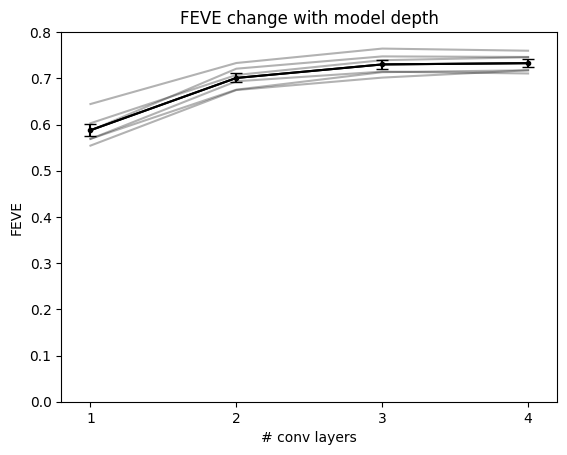

In [8]:
mean = np.mean(feve_mice, axis=0)
sem = np.std(feve_mice, axis=0, ddof=1) / np.sqrt(feve_mice.shape[0])
print(f"mean: {mean}")
print(f"sem: {sem}")

x = [1,2,3,4]

for mice_id in range(0,6):
    plt.plot(x, feve_mice[mice_id], color="BLACK", alpha=0.3)

plt.plot(x, mean, marker="o", markersize= 3, color="BLACK")
plt.errorbar(
    x,
    mean,
    yerr=sem,
    capsize=4,
    color = "BLACK"
)


plt.ylabel("FEVE")
plt.xlabel("# conv layers")
plt.title("FEVE change with model depth")

plt.xlim(0.8,4.2)
plt.xticks([1,2,3,4])
plt.ylim(0.0, 0.8)

output_file_path = os.path.join(output_path, "FEVE_change_with_model_depth")
plt.savefig(output_file_path)
plt.show()